## Introdução


Este notebook traz uma análise mais profunda dos dados disponibilizados. A intenção é ir além dos exercícios do desafio e desenvolver uma análise mais completa e que possa ser utilizada para gerar _insights_ para tomadas de decisão.

Conforme explicado durante a resolução dos exercícios, a base de dados foi criada apenas para esse projeto e com eventos fictícios. Além disso, o banco de dados já foi criado naquela etapa. Dessa forma, esta análise começa já consumindo do banco de dados.

Esta análise foca em entender como os produtos e categorias performam em vendas ao longo do ano. O objetivo é identificar tendências e padrões que permitam corrgiri falhas e explorar bons desempenhos.

## Preparação

O primeiro passo é a instalação das bibiliotecas necessárias para o correto funcionamento do projeto. Pode ser feito usando `pip install requirements.txt`

In [1]:
# importar as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sqlite3

In [2]:
# carregar os dados do banco de dados para um dataframe

# abrir a conexão com o banco de dados
conn = sqlite3.connect('analise_vendas.db')

# criar a query
query = """ 
    SELECT * FROM vendas
"""

# armazenar em um dataframe
df = pd.read_sql_query(query, con=conn)

# fechar a conexão
conn.close()

# exibir o resultado
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [3]:
# conferir a integridade dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        10000 non-null  int64  
 1   data_venda      10000 non-null  str    
 2   cliente         10000 non-null  str    
 3   produto         10000 non-null  str    
 4   categoria       10000 non-null  str    
 5   quantidade      10000 non-null  int64  
 6   preco_unitario  10000 non-null  float64
 7   vendedor        10000 non-null  str    
 8   cidade          10000 non-null  str    
 9   estado          10000 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 781.4 KB


In [4]:
# tratamento da coluna de data para o formato data
df['data_venda'] = pd.to_datetime(df['data_venda'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        10000 non-null  int64         
 1   data_venda      10000 non-null  datetime64[us]
 2   cliente         10000 non-null  str           
 3   produto         10000 non-null  str           
 4   categoria       10000 non-null  str           
 5   quantidade      10000 non-null  int64         
 6   preco_unitario  10000 non-null  float64       
 7   vendedor        10000 non-null  str           
 8   cidade          10000 non-null  str           
 9   estado          10000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 781.4 KB


In [5]:
# consultar os anos das vendas
df['data_venda'].dt.year.unique()

array([2024], dtype=int32)

Como as vendas ocorreram todas no mesmo ano não é necessário continuar usando o ano nas análises.

In [6]:
# criar a coluna de faturamento de cada venda
df['faturamento'] = df['quantidade'] * df['preco_unitario']

df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28


In [7]:
# criar uma função para tratar a exibição de valores de moeda
# essa função deve alterar apenas a exibição, sem modificar o valor no dataframe (que permanece como float)

def exibe_moeda(valor, pos=None):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


# testando a função
df.head().style.format({'faturamento': exibe_moeda})

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento
0,1,2024-09-27 00:00:00,Pietra,Mouse,Eletrônicos,3,84.740000,Ana,Belo Horizonte,RJ,"R$ 254,22"
1,2,2024-01-21 00:00:00,Vinicius,Monitor,Eletrônicos,3,950.340000,Bruno,São Paulo,RS,"R$ 2.851,02"
2,3,2024-08-02 00:00:00,Yago,Mouse,Eletrônicos,3,79.130000,Eduardo,Curitiba,SP,"R$ 237,39"
3,4,2024-04-09 00:00:00,Lara,Notebook,Eletrônicos,3,3471.470000,Ana,Rio de Janeiro,RJ,"R$ 10.414,41"
4,5,2024-05-29 00:00:00,Levi,Fone,Eletrônicos,4,208.320000,Eduardo,São Paulo,RS,"R$ 833,28"


In [8]:
# criar uma coluna para armazenar exclusivamente o mês da compra

# primeiro um dicionário para traduzir os nomes dos meses para português
meses_pt={
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril',
    5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto',
    9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}

# extrair o mês da data e já converter usando o dicionário
df['mes'] = df['data_venda'].dt.month.map(meses_pt)

# conferir o resultado
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento,mes
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22,Setembro
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02,Janeiro
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39,Agosto
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41,Abril
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28,Maio


In [9]:
# criar uma coluna para armazenar exclusivamente o dia da semana da compra

# novamente, primeiro um dicionário para converter o dia da semana para português
dias_semana_pt={
    0:'Segunda-feira', 1:'Terça-feira',
    2:'Quarta-feira', 3:'Quinta-feira', 4:'Sexta-feira',
    5:'Sábado', 6:'Domingo'
}

# extrair o dia da semana de cada data, já traduzindo
df['dia_semana'] = df['data_venda'].dt.day_of_week.map(dias_semana_pt)

# conferir o resultado
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento,mes,dia_semana
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22,Setembro,Sexta-feira
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02,Janeiro,Domingo
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39,Agosto,Sexta-feira
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41,Abril,Terça-feira
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28,Maio,Quarta-feira


In [10]:
# criar uma coluna com o dia da venda. Pode ser usada para entender comportamento das vendas ao longo do mês
df['dia_mes'] = df['data_venda'].dt.day

# conferir o resultado
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento,mes,dia_semana,dia_mes
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22,Setembro,Sexta-feira,27
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02,Janeiro,Domingo,21
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39,Agosto,Sexta-feira,2
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41,Abril,Terça-feira,9
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28,Maio,Quarta-feira,29


In [11]:
df['categoria'].value_counts()

categoria
Eletrônicos    5024
Livros         1992
Móveis         1947
Acessórios     1037
Name: count, dtype: int64

Aqui se conclui a preparação dos dados. Assim, pode-se iniciar as análises.

## Evolução mensal de vendas

Inicialmente, uma visão gráfica sobre como o total de vendas se comportou ao longo do ano.

In [12]:
# gráfico de evolução do total de vendas ao longo do ano

# um novo dataset, exclusivo para ser usado nesse gráfico. Agrupa as vendas por mês e organizar em ordem do calendário
df_evolucao_mensal = df.groupby([df['data_venda'].dt.month , 'mes'])['faturamento'].sum().reset_index().drop(columns='data_venda')

# df['data_venda'].dt.month passa ao groupby a ordem correta dos meses.
# reset_index() para que as colunas com número e nome do mes virem colunas reais, não apenas índices.
# drop('data_venda') para que não apareça essa coluna no df pronto


# conferir o resultado
df_evolucao_mensal


,mes,faturamento
0,Janeiro,1332505.24
1,Fevereiro,1414699.44
2,Março,1561420.22
3,Abril,1571459.42
4,Maio,1537043.09
5,Junho,1346568.09
6,Julho,1528937.90
7,Agosto,1531974.02
8,Setembro,1560269.23
9,Outubro,1423821.79


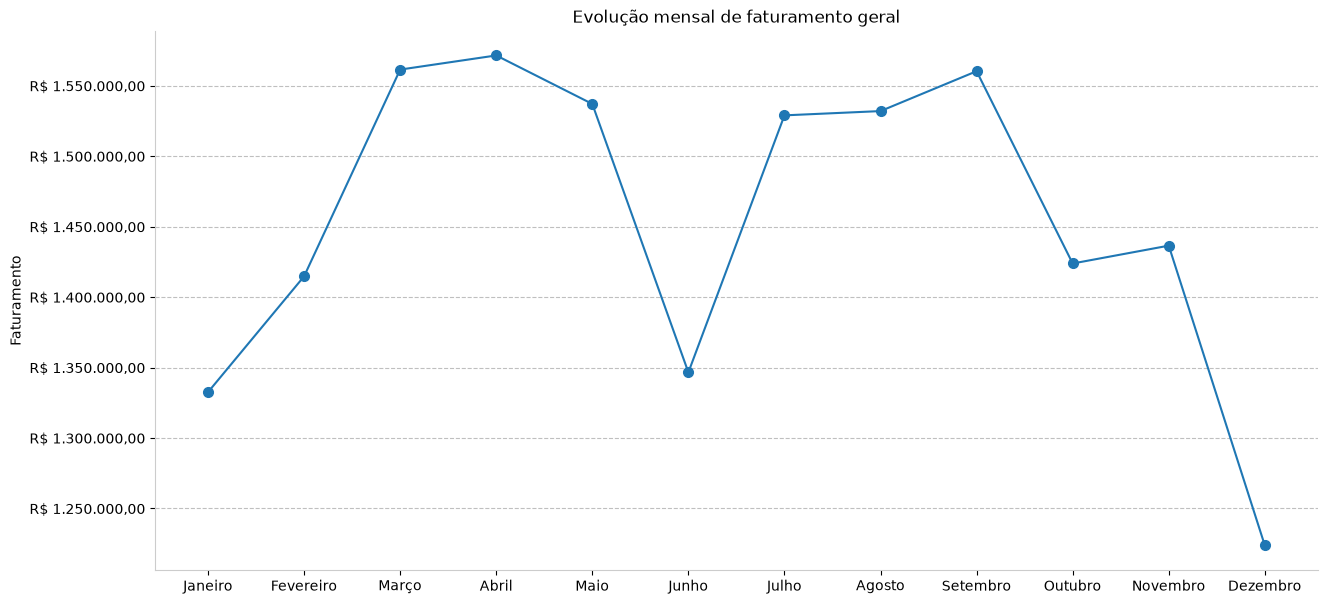

In [79]:

# instanciar o gráfico
fig, ax = plt.subplots(figsize=(15,7))

# tipo de gráfico e eixos de análise
ax.plot(
    df_evolucao_mensal['mes'],
    df_evolucao_mensal['faturamento'],
    marker = 'o',
    markersize=7
)

ax.set_title('Evolução mensal de faturamento geral')
ax.set_ylabel('Faturamento')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(exibe_moeda)) # para tratar a visualizaçõa dos valores como moeda

#tratamento visual das bordas do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# grid do eixo y
ax.grid(axis='y', linestyle='--', alpha=0.8)

plt.show()

Curiosamente o período do Natal, tradicional época de aquecimento do comércio, é o mês de pior desempenho da empresa.

A seguir uma investigação mensal por setor, em volume de vendas.

In [14]:
# gráfico de evolução mensal de vendas por categoria ao longo do ano

# um novo dataset, exclusivo para ser usado nesse gráfico. Agrupa as vendas por mês e por produto e organizar em ordem do calendário
# diferente do anterior, esse df agrupa o volume de vendas, não o quantidade. Feito dessa forma pois os produtos de diferentes categorias têm valores diferentes.
df_evolucao_mensal_produtos = df.groupby([df['data_venda'].dt.month , 'mes', 'categoria'])['quantidade'].sum().reset_index()

# pivotar o df para que fique no formato de tabela por categoria
df_evolucao_mensal_produtos = df_evolucao_mensal_produtos.pivot(index=['data_venda', 'mes'], columns='categoria', values='quantidade')
# remover a coluna de data_venda que ficou como índice
df_evolucao_mensal_produtos.reset_index(level = 'data_venda', drop= True, inplace=True)

# Apaga o "título" das colunas
df_evolucao_mensal_produtos.columns.name = None
df_evolucao_mensal_produtos.reset_index(inplace=True)

# conferir o resultado
df_evolucao_mensal_produtos


,mes,Acessórios,Eletrônicos,Livros,Móveis
0,Janeiro,213,1012,454,466
1,Fevereiro,246,1056,369,356
2,Março,212,1112,448,417
3,Abril,218,1078,474,393
4,Maio,206,1076,406,439
5,Junho,191,1062,371,384
6,Julho,203,938,351,459
7,Agosto,239,1016,467,406
8,Setembro,181,1040,390,433
9,Outubro,280,1069,455,370


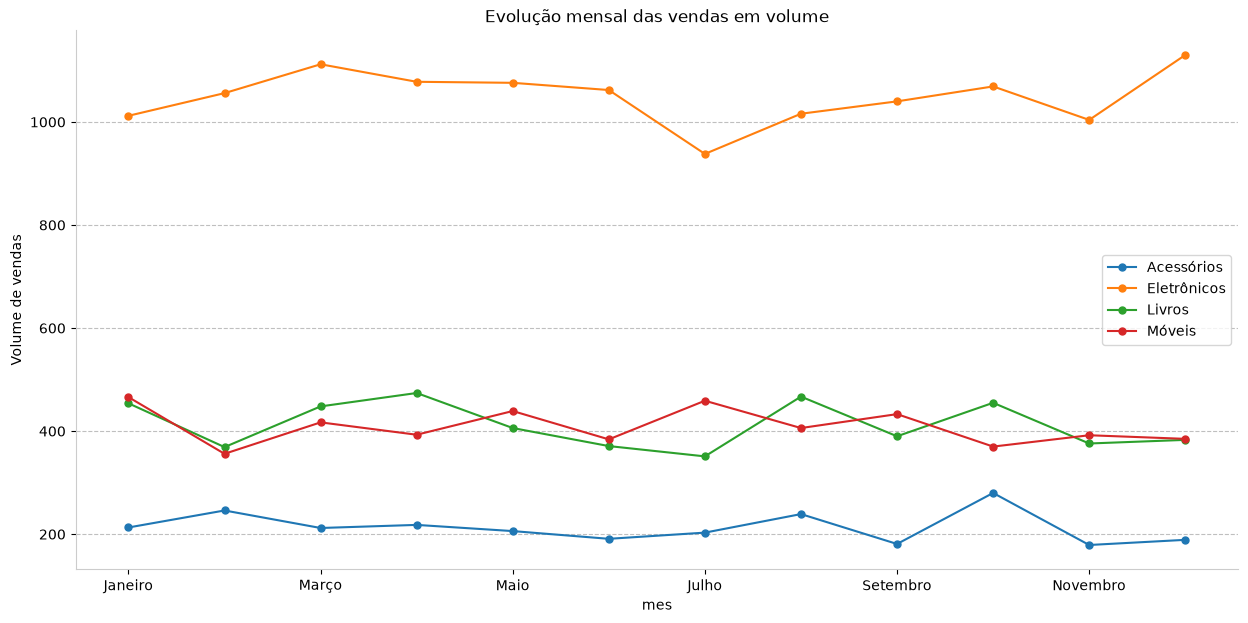

In [15]:
# instanciar o gráfico
fig, ax = plt.subplots(figsize=(15,7))

# tipo de gráfico e eixos de análise
df_evolucao_mensal_produtos.plot(
    'mes',
    ax=ax,
    marker = 'o',
    markersize=5
)

ax.set_title('Evolução mensal das vendas em volume')
ax.set_ylabel('Volume de vendas')
# ax.yaxis.set_major_formatter(ticker.FuncFormatter(exibe_moeda)) # para tratar a visualizaçõa dos valores como moeda

#tratamento visual das bordas do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# grid do eixo y
ax.grid(axis='y', linestyle='--', alpha=0.8)

plt.show()

Se não há quedas notáveis em volume de vendas em Janeiro, Junho e Dezembro, porquê o faturamento cai tanto?

Para entender, um gráfico visualizando a evolução por categoria, mas agora em relação ao faturamento.

In [16]:
# gráfico de evolução mensal de faturamento por categoria ao longo do ano

# um novo dataset, exclusivo para ser usado nesse gráfico. Agrupa as vendas por mês e por produto e organiza em ordem do calendário
df_evolucao_mensal_faturamento = df.groupby([df['data_venda'].dt.month , 'mes', 'categoria'])['faturamento'].sum().reset_index()

# pivotar o df para que fique no formato de tabela por categoria
df_evolucao_mensal_faturamento = df_evolucao_mensal_faturamento.pivot(index=['data_venda', 'mes'], columns='categoria', values='faturamento')
# remover a coluna de data_venda que ficou como índice
df_evolucao_mensal_faturamento.reset_index(level = 'data_venda', drop= True, inplace=True)

# Apaga o "título" das colunas
df_evolucao_mensal_faturamento.columns.name = None
df_evolucao_mensal_faturamento.reset_index(inplace=True)

# conferir o resultado
df_evolucao_mensal_faturamento


,mes,Acessórios,Eletrônicos,Livros,Móveis
0,Janeiro,38116.25,798331.45,49498.29,446559.25
1,Fevereiro,44174.22,986859.83,40582.82,343082.57
2,Março,38278.77,1077046.08,49722.39,396372.98
3,Abril,39454.40,1094433.39,52324.90,385246.73
4,Maio,36772.94,1024336.16,44472.41,431461.58
5,Junho,34308.03,912385.22,41041.70,358833.14
6,Julho,36824.39,1002220.10,38228.58,451664.83
7,Agosto,43101.89,1046293.70,51804.38,390774.05
8,Setembro,32801.17,1078442.00,42908.16,406117.90
9,Outubro,50213.01,959119.21,50171.30,364318.27


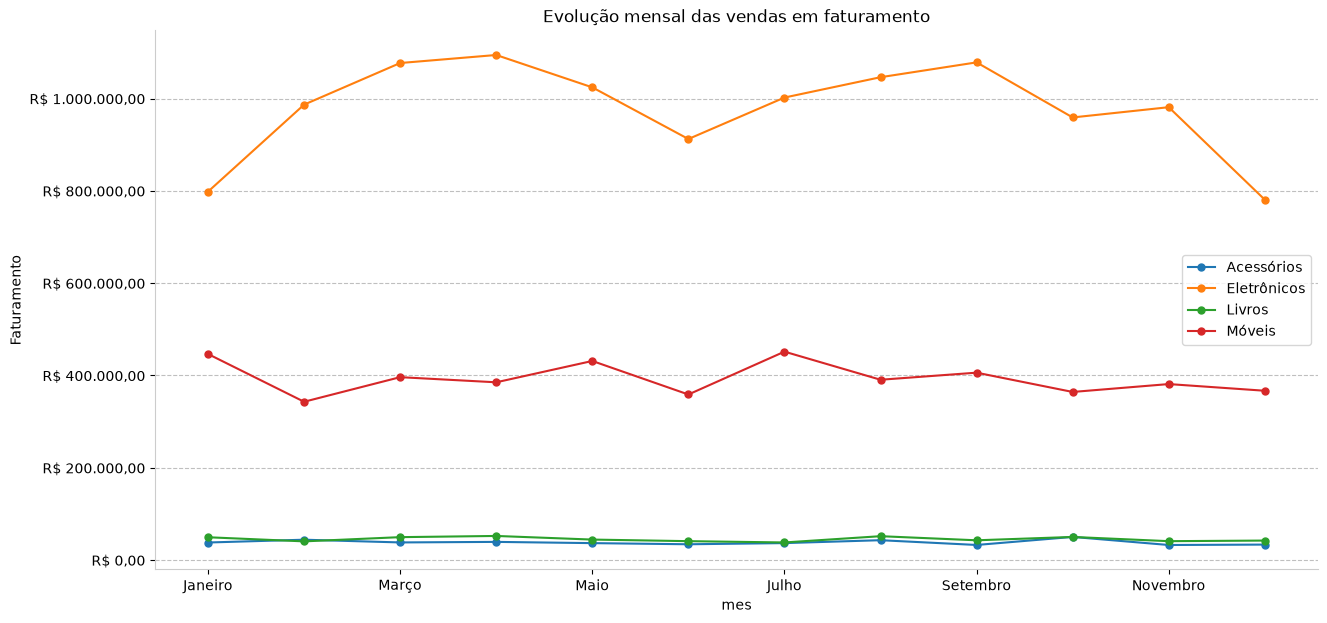

In [17]:
# instanciar o gráfico
fig, ax = plt.subplots(figsize=(15,7))

# tipo de gráfico e eixos de análise
df_evolucao_mensal_faturamento.plot(
    'mes',
    ax=ax,
    marker = 'o',
    markersize=5
)

ax.set_title('Evolução mensal das vendas em faturamento')
ax.set_ylabel('Faturamento')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(exibe_moeda)) # para tratar a visualizaçõa dos valores como moeda

#tratamento visual das bordas do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# grid do eixo y
ax.grid(axis='y', linestyle='--', alpha=0.8)

plt.show()

Os setores de acessórios, livros e móveis indicam uma certa estabilidade de faturamento ao longo do ano. Já o setor de eletrônicos tem quedas notáveis em Janeiro, Junho e Dezembro, exatamente os mesmos meses em que se registra queda no faturamento total da empresa. Assim, pode-se afirmar que essa queda no faturamento total é causada pela queda no faturamento do setor de eletrônicos. Soma-se a isso o fato do volume de venda dos produtos eletrônicos ser mais elevado que o volume de venda dos produtos de outras categorias, o que faz com que variações nessa categoria tenham maior impacto no cenário geral.

## Análise específica do setor de eletrônicos

Como identificado acima, o setor de eletrônicos tem grande impacto no desempenho da empresa como um todo. Os gráficos mostram que, apesar de não haver queda no volume de vendas, há queda no faturamento dessa categoria nos meses de Janeiro, Junho e Dezembro. Assim, é importante investigar o responsável por essa queda de faturamento.

In [18]:
# criar um df apenas com produtos eletrônicos
df_eletronicos = df[df['categoria']=='Eletrônicos'].reset_index()
df_eletronicos

,index,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento,mes,dia_semana,dia_mes
0,0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22,Setembro,Sexta-feira,27
1,1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02,Janeiro,Domingo,21
2,2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39,Agosto,Sexta-feira,2
3,3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41,Abril,Terça-feira,9
4,4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28,Maio,Quarta-feira,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,9989,9990,2024-09-27,Benício,Notebook,Eletrônicos,2,3515.25,Eduardo,Curitiba,PR,7030.50,Setembro,Sexta-feira,27
5020,9990,9991,2024-05-04,Ana Julia,Teclado,Eletrônicos,1,146.71,Ana,São Paulo,PR,146.71,Maio,Sábado,4
5021,9992,9993,2024-02-13,Milena,Notebook,Eletrônicos,2,3238.53,Bruno,Rio de Janeiro,SP,6477.06,Fevereiro,Terça-feira,13
5022,9995,9996,2024-11-19,Cauã,Teclado,Eletrônicos,1,141.84,Carlos,Belo Horizonte,RJ,141.84,Novembro,Terça-feira,19


In [ ]:
# avaliar o preço médio dos produtos eletrônicos
df_epreco = df_eletronicos.groupby(['produto'])['preco_unitario'].mean()
df_epreco.to_frame().style.format(exibe_moeda) # para exibir corretamente como moeda

,preco_unitario
produto,
Fone,"R$ 200,40"
Monitor,"R$ 902,80"
Mouse,"R$ 79,70"
Notebook,"R$ 3.507,76"
Teclado,"R$ 150,09"


Devido ao alto preço médio dos notebooks em comparação aos outros produtos, suspeita-se que alterações em suas vendas tenham maior impacto na receita da empresa. a seguir um gráfico de vcolume de vendas da categoria "eletrônicos" com destaque às vendas de notebook. Esse gráfico visa identificar se de fato os notebooks são os responsáveis pelas quedas de faturamento.

In [ ]:
# novo df para o gráfico
df_eletronicos_produto = df_eletronicos.groupby([df_eletronicos['data_venda'].dt.month,'mes','produto'])['quantidade'].sum().reset_index()

# pivotar a tabela
df_eletronicos_produto = df_eletronicos_produto.pivot(index=['data_venda','mes'], columns='produto',values='quantidade')

# Apaga o "título" das colunas
df_eletronicos_produto.columns.name = None
df_eletronicos_produto.reset_index(inplace=True)

# remover a coluna de data_venda que servia apenas para ordenar os meses
df_eletronicos_produto.drop(columns=['data_venda'], inplace=True)

df_eletronicos_produto

,mes,Fone,Monitor,Mouse,Notebook,Teclado
0,Janeiro,199,182,249,154,228
1,Fevereiro,205,246,214,192,199
2,Março,213,288,178,205,228
3,Abril,192,252,209,221,204
4,Maio,243,215,195,210,213
5,Junho,213,248,199,169,233
6,Julho,184,168,199,223,164
7,Agosto,199,180,213,230,194
8,Setembro,191,188,220,235,206
9,Outubro,214,236,229,187,203


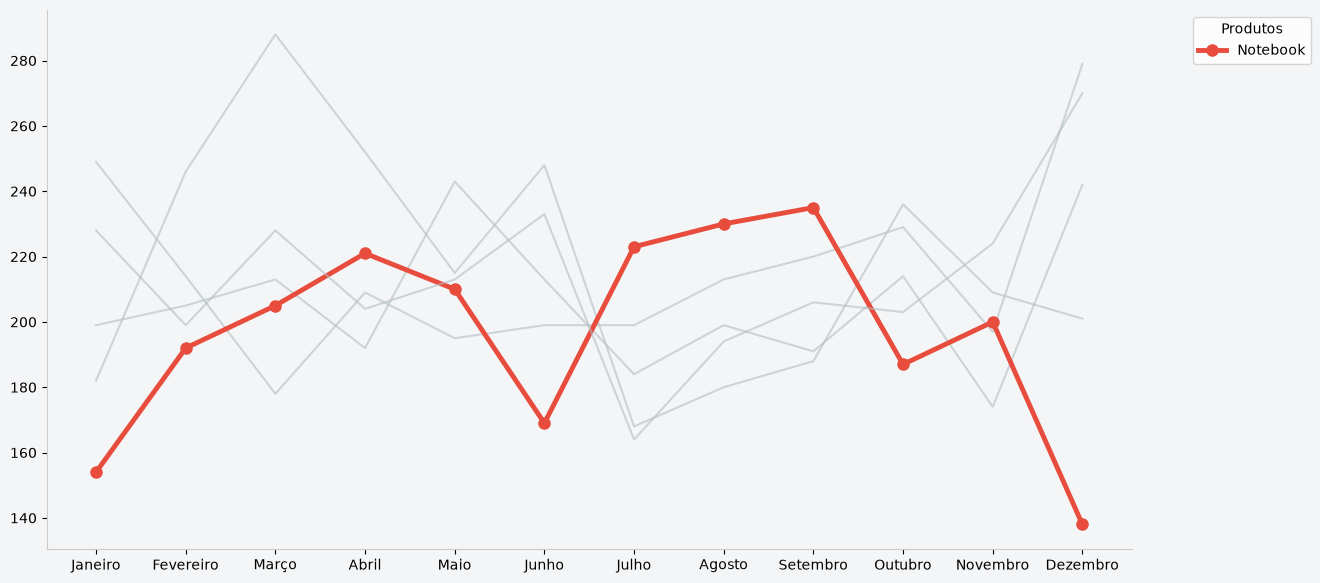

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#f4f5f7') 
ax.set_facecolor('#f4f5f7')

# Passamos por cada produto dentro das colunas
for produto in df_eletronicos_produto.columns:
    if produto == 'mes':
        continue # para não plotar a coluna de mês
    
    if produto == 'Notebook':
        # linha grossa, cor vermelha de alerta e marcadores evidentes
        ax.plot(
            df_eletronicos_produto['mes'], 
            df_eletronicos_produto[produto], 
            color='#e74c3c',      # Vermelho vibrante
            linewidth=3.5,        # Linha bem grossa
            marker='o',
            markersize=8,
            label='Notebook' # Nome específico para a legenda
        )
    else:
        # linhas finas, cinzas e levemente transparentes
        ax.plot(
            df_eletronicos_produto['mes'], 
            df_eletronicos_produto[produto], 
            color='#b2bec3',      # Cinza claro
            linewidth=1.5,
            alpha=0.6,            # Deixa a linha 40% transparente
            # label=produto         # Mantém o nome original na legenda
        )

# Tira a poluição visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Legenda fora do gráfico
plt.legend(title='Produtos', bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.tight_layout()
plt.show()

Conforme suspeitas anteriores, os meses de queda de vendas de notebook são exatamente os mesmos meses de queda do faturamento da empresa. Assim conclui-se que esse produto, devido principalmente ao seu alto valor, é responsável pelas quedas identificadas.